# 🔐 SigAuth Complete Backend - Production Ready

## Advanced Forgery-Resilient Signature Authentication
### Using Siamese Metric Learning and Digital Tamper Detection

---

**Features:**
- Siamese Network with ResNet-18 backbone for skilled forgery detection
- CNN-based Tamper Detection for digital copy-paste forgeries
- Complete training pipeline with metrics (FAR, FRR, EER, Precision, Recall, F1)
- Flask API for frontend integration via ngrok

**Datasets Required (upload as ZIP files):**
1. `task1.zip` - SVC2004 Task 1 signature images
2. `task2.zip` - SVC2004 Task 2 signature images  
3. `synthetic_tamper.zip` - Clean and tampered signature images

## 📦 Cell 1: Install Dependencies

In [1]:
# Install required packages
!pip install flask flask-cors pyngrok pillow scikit-learn matplotlib seaborn tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


## 📁 Cell 2: Upload and Extract Datasets

**IMPORTANT:** Upload your ZIP files using the file browser on the left panel:
1. Click the folder icon 📁
2. Click the upload button ⬆️
3. Upload: `task1.zip`, `task2.zip`, `synthetic_tamper.zip`
4. Run this cell AFTER uploading

In [2]:
import os
import zipfile

# Create directories
os.makedirs('datasets/svc2004/task1', exist_ok=True)
os.makedirs('datasets/svc2004/task2', exist_ok=True)
os.makedirs('datasets/tamper/clean', exist_ok=True)
os.makedirs('datasets/tamper/tampered', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)
os.makedirs('results', exist_ok=True)

def extract_zip(zip_path, extract_to):
    """Extract ZIP file to specified directory"""
    if os.path.exists(zip_path):
        print(f"📦 Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"   ✅ Extracted to {extract_to}")
        return True
    else:
        print(f"   ⚠️ {zip_path} not found. Please upload it.")
        return False

# Extract datasets
print("="*50)
print("📂 EXTRACTING DATASETS")
print("="*50)

# Try different possible paths for uploaded files
task1_paths = ['task1.zip', '/content/task1.zip', 'Task1.zip', '/content/Task1.zip']
task2_paths = ['task2.zip', '/content/task2.zip', 'Task2.zip', '/content/Task2.zip']
tamper_paths = ['synthetic_tamper.zip', '/content/synthetic_tamper.zip', 'tamper.zip', '/content/tamper.zip']

for path in task1_paths:
    if extract_zip(path, 'datasets/svc2004/task1'):
        break

for path in task2_paths:
    if extract_zip(path, 'datasets/svc2004/task2'):
        break

for path in tamper_paths:
    if extract_zip(path, 'datasets/tamper'):
        break

print("\n" + "="*50)
print("📊 DATASET SUMMARY")
print("="*50)

def count_images(folder):
    """Recursively count image files"""
    count = 0
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    count += 1
    return count

task1_count = count_images('datasets/svc2004/task1')
task2_count = count_images('datasets/svc2004/task2')
clean_count = count_images('datasets/tamper/clean')
tampered_count = count_images('datasets/tamper/tampered')

print(f"Task 1 images: {task1_count}")
print(f"Task 2 images: {task2_count}")
print(f"Clean images: {clean_count}")
print(f"Tampered images: {tampered_count}")
print(f"\nTotal: {task1_count + task2_count + clean_count + tampered_count} images")

📂 EXTRACTING DATASETS
   ⚠️ task1.zip not found. Please upload it.
   ⚠️ /content/task1.zip not found. Please upload it.
📦 Extracting Task1.zip...
   ✅ Extracted to datasets/svc2004/task1
   ⚠️ task2.zip not found. Please upload it.
   ⚠️ /content/task2.zip not found. Please upload it.
📦 Extracting Task2.zip...
   ✅ Extracted to datasets/svc2004/task2
📦 Extracting synthetic_tamper.zip...
   ✅ Extracted to datasets/tamper

📊 DATASET SUMMARY
Task 1 images: 1600
Task 2 images: 1600
Clean images: 0
Tampered images: 1550

Total: 4750 images


## 🧠 Cell 3: Define Model Architectures

In [3]:
class SiameseNetwork(nn.Module):
    """
    Siamese Network with ResNet-18 backbone for signature verification.
    Uses metric learning to compare signature embeddings.
    FIXED: Removed inplace operations and ensured deterministic behavior.
    """
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork, self).__init__()

        # ResNet-18 backbone (pretrained)
        resnet = models.resnet18(pretrained=True)

        # Modify first conv layer for grayscale input
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Copy pretrained weights (average across RGB channels)
        with torch.no_grad():
            self.conv1.weight = nn.Parameter(
                resnet.conv1.weight.mean(dim=1, keepdim=True)
            )

        # Rest of ResNet
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.avgpool = resnet.avgpool

        # ✅ FIXED: Embedding layer without inplace operations
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),  # Removed inplace=True
            nn.Dropout(0.5),
            nn.Linear(256, embedding_dim)
        )

    def forward_one(self, x):
        """Forward pass for single image - DETERMINISTIC when in eval mode"""
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        # L2 normalize embedding
        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, anchor, positive=None, negative=None):
        """Forward pass for triplet or pair"""
        anchor_out = self.forward_one(anchor)

        if positive is not None and negative is not None:
            # Triplet mode
            positive_out = self.forward_one(positive)
            negative_out = self.forward_one(negative)
            return anchor_out, positive_out, negative_out
        elif positive is not None:
            # Pair mode
            positive_out = self.forward_one(positive)
            return anchor_out, positive_out
        else:
            # Single embedding mode
            return anchor_out


class TamperDetectionCNN(nn.Module):
    """
    Lightweight CNN for detecting digital tampering in signatures.
    Detects copy-paste, noise inconsistencies, and edge artifacts.
    FIXED: Removed inplace operations for deterministic behavior.
    """
    def __init__(self):
        super(TamperDetectionCNN, self).__init__()

        # ✅ FIXED: Feature extraction without inplace operations
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),  # Removed inplace=True
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),  # Removed inplace=True
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),  # Removed inplace=True
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),  # Removed inplace=True
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),  # Removed inplace=True
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),  # Removed inplace=True
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),  # Removed inplace=True
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # ✅ FIXED: Classifier without inplace operations
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),  # Removed inplace=True
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),  # Removed inplace=True
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Binary: clean vs tampered
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Initialize models
siamese_model = SiameseNetwork(embedding_dim=128).to(device)
tamper_model = TamperDetectionCNN().to(device)

print("✅ Models initialized with DETERMINISTIC architecture!")
print(f"   Siamese Network parameters: {sum(p.numel() for p in siamese_model.parameters()):,}")
print(f"   Tamper CNN parameters: {sum(p.numel() for p in tamper_model.parameters()):,}")
print("\n🔧 Changes made:")
print("   - Removed inplace=True from all ReLU layers")
print("   - Ensures 100% deterministic behavior in eval mode")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


✅ Models initialized with DETERMINISTIC architecture!
   Siamese Network parameters: 11,334,464
   Tamper CNN parameters: 2,746,594

🔧 Changes made:
   - Removed inplace=True from all ReLU layers
   - Ensures 100% deterministic behavior in eval mode


## 📊 Cell 4: Define Datasets and Data Loaders

In [4]:
class SVC2004Dataset(Dataset):
    """
    Dataset for SVC2004 signature verification.
    SVC2004 labeling:
    - S1-S20: Genuine signatures
    - S21-S40: Skilled forgeries
    """
    def __init__(self, root_dirs, transform=None, triplet=True):
        self.transform = transform
        self.triplet = triplet
        self.samples = []
        self.user_samples = {}

        for root_dir in root_dirs:
            if not os.path.exists(root_dir):
                continue
            for dirpath, dirnames, filenames in os.walk(root_dir):
                for filename in filenames:
                    if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        continue
                    filepath = os.path.join(dirpath, filename)
                    name = os.path.splitext(filename)[0].upper()
                    user_id = None
                    sample_id = None

                    if 'U' in name and 'S' in name:
                        try:
                            parts = name.replace('U', '').split('S')
                            user_id = int(parts[0])
                            sample_id = int(parts[1].split('_')[0].split('-')[0])
                        except:
                            pass

                    if user_id is None:
                        try:
                            parent = os.path.basename(dirpath)
                            if parent.startswith('U') or parent.startswith('u'):
                                user_id = int(parent[1:])
                                sample_id = int(''.join(filter(str.isdigit, filename.split('.')[0])) or 1)
                        except:
                            continue

                    if user_id is None:
                        continue

                    is_genuine = sample_id <= 20
                    self.samples.append((user_id, sample_id, filepath, is_genuine))

                    if user_id not in self.user_samples:
                        self.user_samples[user_id] = {'genuine': [], 'forged': []}

                    if is_genuine:
                        self.user_samples[user_id]['genuine'].append(filepath)
                    else:
                        self.user_samples[user_id]['forged'].append(filepath)

        valid_users = [uid for uid, samples in self.user_samples.items()
                      if len(samples['genuine']) >= 2 and len(samples['forged']) >= 1]
        self.valid_users = valid_users
        print(f"   Loaded {len(self.samples)} samples from {len(self.valid_users)} valid users")

    def __len__(self):
        return len(self.valid_users) * 20

    def __getitem__(self, idx):
        user_id = self.valid_users[idx % len(self.valid_users)]
        user_data = self.user_samples[user_id]

        genuine_samples = user_data['genuine']
        indices = np.random.choice(len(genuine_samples), size=2, replace=len(genuine_samples)<2)
        anchor_path = genuine_samples[indices[0]]
        positive_path = genuine_samples[indices[1]]

        forged_samples = user_data['forged']
        negative_path = np.random.choice(forged_samples)

        anchor = self._load_image(anchor_path)
        positive = self._load_image(positive_path)
        negative = self._load_image(negative_path)

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative, user_id

    def _load_image(self, path):
        img = Image.open(path).convert('L')
        return img


class TamperDataset(Dataset):
    """
    Dataset for tamper detection.
    Clean images (label=0) vs Tampered images (label=1)
    """
    def __init__(self, clean_dir, tampered_dir, transform=None):
        self.transform = transform
        self.samples = []

        if os.path.exists(clean_dir):
            for root, _, files in os.walk(clean_dir):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        self.samples.append((os.path.join(root, f), 0))

        if os.path.exists(tampered_dir):
            for root, _, files in os.walk(tampered_dir):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        self.samples.append((os.path.join(root, f), 1))

        clean_count = sum(1 for _, l in self.samples if l == 0)
        tampered_count = sum(1 for _, l in self.samples if l == 1)
        print(f"   Loaded {len(self.samples)} tamper samples")
        print(f"   Clean: {clean_count}, Tampered: {tampered_count}")

        if clean_count == 0:
            print("   ⚠️  WARNING: No clean images found! Tamper model will be unreliable.")
            print("   ⚠️  WORKAROUND: Will use genuine SVC2004 signatures as clean samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label


# ============================================================
# TRANSFORMS - CRITICAL: Separate train vs inference transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(5),       # Mild augmentation for training only
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ✅ CRITICAL: val_transform has NO randomness - deterministic inference
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("✅ Transforms defined:")
print("   train_transform: WITH RandomRotation + RandomAffine (for training)")
print("   val_transform: NO randomness (for inference)")

# ============================================================
# CREATE DATASETS
# ============================================================
print("\n" + "="*50)
print("📊 CREATING DATASETS")
print("="*50)

print("\n🔹 SVC2004 Signature Dataset:")
svc_dataset = SVC2004Dataset(
    root_dirs=['datasets/svc2004/task1', 'datasets/svc2004/task2'],
    transform=train_transform,
    triplet=True
)

print("\n🔹 Tamper Detection Dataset:")
tamper_dataset = TamperDataset(
    clean_dir='datasets/tamper/clean',
    tampered_dir='datasets/tamper/tampered',
    transform=train_transform
)

# ============================================================
# ✅ FIX: If no clean images, use genuine SVC2004 sigs as clean
# ============================================================
clean_count = sum(1 for _, l in tamper_dataset.samples if l == 0)
if clean_count == 0:
    print("\n🔧 AUTO-FIX: Adding genuine SVC2004 signatures as 'clean' samples...")
    added = 0
    for uid, data in svc_dataset.user_samples.items():
        for gpath in data['genuine']:
            tamper_dataset.samples.append((gpath, 0))  # label 0 = clean
            added += 1
    print(f"   Added {added} genuine signatures as clean samples")
    clean_count_new = sum(1 for _, l in tamper_dataset.samples if l == 0)
    tampered_count_new = sum(1 for _, l in tamper_dataset.samples if l == 1)
    print(f"   New balance: Clean={clean_count_new}, Tampered={tampered_count_new}")

# Split datasets
from torch.utils.data import random_split

svc_train_size = int(0.8 * len(svc_dataset))
svc_val_size = len(svc_dataset) - svc_train_size
svc_train, svc_val = random_split(svc_dataset, [svc_train_size, svc_val_size])

tamper_train_size = int(0.8 * len(tamper_dataset))
tamper_val_size = len(tamper_dataset) - tamper_train_size
tamper_train, tamper_val = random_split(tamper_dataset, [tamper_train_size, tamper_val_size])

# Data loaders
svc_train_loader = DataLoader(svc_train, batch_size=32, shuffle=True, num_workers=2)
svc_val_loader = DataLoader(svc_val, batch_size=32, shuffle=False, num_workers=2)
tamper_train_loader = DataLoader(tamper_train, batch_size=32, shuffle=True, num_workers=2)
tamper_val_loader = DataLoader(tamper_val, batch_size=32, shuffle=False, num_workers=2)

print(f"\n✅ SVC2004: Train={svc_train_size}, Val={svc_val_size}")
print(f"✅ Tamper: Train={tamper_train_size}, Val={tamper_val_size}")


✅ Transforms defined:
   train_transform: WITH RandomRotation + RandomAffine (for training)
   val_transform: NO randomness (for inference)

📊 CREATING DATASETS

🔹 SVC2004 Signature Dataset:
   Loaded 3200 samples from 40 valid users

🔹 Tamper Detection Dataset:
   Loaded 1550 tamper samples
   Clean: 0, Tampered: 1550
   ⚠️  WARNING: No clean images found! Tamper model will be unreliable.
   ⚠️  WORKAROUND: Will use genuine SVC2004 signatures as clean samples.

🔧 AUTO-FIX: Adding genuine SVC2004 signatures as 'clean' samples...
   Added 1600 genuine signatures as clean samples
   New balance: Clean=1600, Tampered=1550

✅ SVC2004: Train=640, Val=160
✅ Tamper: Train=2520, Val=630


## 🏋️ Cell 5: Train Siamese Network for Skilled Forgery Detection

In [5]:
class TripletLoss(nn.Module):
    """Triplet loss with hard margin"""
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()


def train_siamese(model, train_loader, val_loader, epochs=50, lr=0.0001):
    """Train Siamese network with triplet loss"""

    criterion = TripletLoss(margin=1.0)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'accuracy': []}
    best_loss = float('inf')

    print("\n" + "="*60)
    print("🏋️ TRAINING SIAMESE NETWORK (Skilled Forgery Detection)")
    print("="*60)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for anchor, positive, negative, _ in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            anchor_out, positive_out, negative_out = model(anchor, positive, negative)
            loss = criterion(anchor_out, positive_out, negative_out)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for anchor, positive, negative, _ in val_loader:
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                anchor_out, positive_out, negative_out = model(anchor, positive, negative)
                loss = criterion(anchor_out, positive_out, negative_out)
                val_loss += loss.item()

                # Calculate accuracy (positive should be closer than negative)
                pos_dist = F.pairwise_distance(anchor_out, positive_out)
                neg_dist = F.pairwise_distance(anchor_out, negative_out)
                correct += (pos_dist < neg_dist).sum().item()
                total += anchor.size(0)

        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / total * 100

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['accuracy'].append(accuracy)

        scheduler.step(avg_val_loss)

        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Accuracy: {accuracy:.2f}%")

        # Save best model
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
            }, 'saved_models/siamese_best.pth')
            print(f"   💾 Best model saved! (Loss: {best_loss:.4f})")

    return history


# Train if dataset is available
if len(svc_dataset) > 0:
    EPOCHS = 30  # Adjust based on your needs (more = better, but slower)
    siamese_history = train_siamese(siamese_model, svc_train_loader, svc_val_loader, epochs=EPOCHS)
else:
    print("⚠️ No SVC2004 data found. Please upload task1.zip and task2.zip")


🏋️ TRAINING SIAMESE NETWORK (Skilled Forgery Detection)


Epoch 1/30: 100%|██████████| 20/20 [00:07<00:00,  2.67it/s, loss=0.9603]


   Train Loss: 0.9958 | Val Loss: 0.9776 | Accuracy: 63.75%
   💾 Best model saved! (Loss: 0.9776)


Epoch 2/30: 100%|██████████| 20/20 [00:04<00:00,  4.10it/s, loss=0.9793]


   Train Loss: 1.0006 | Val Loss: 0.9840 | Accuracy: 54.37%


...

   Train Loss: 0.0707 | Val Loss: 0.2762 | Accuracy: 93.75%


Epoch 29/30: 100%|██████████| 20/20 [00:02<00:00,  7.04it/s, loss=0.1665]


   Train Loss: 0.0821 | Val Loss: 0.3475 | Accuracy: 92.50%


Epoch 30/30: 100%|██████████| 20/20 [00:02<00:00,  7.27it/s, loss=0.0195]


   Train Loss: 0.0474 | Val Loss: 0.3452 | Accuracy: 90.62%


## 🏋️ Cell 6: Train Tamper Detection CNN

In [6]:
def train_tamper_detector(model, train_loader, val_loader, epochs=30, lr=0.0001):
    """Train tamper detection CNN"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    best_acc = 0.0

    print("\n" + "="*60)
    print("🏋️ TRAINING TAMPER DETECTION CNN")
    print("="*60)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)

        # Calculate metrics
        accuracy = (np.array(all_preds) == np.array(all_labels)).mean() * 100
        precision = precision_score(all_labels, all_preds, average='binary', zero_division=0) * 100
        recall = recall_score(all_labels, all_preds, average='binary', zero_division=0) * 100
        f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0) * 100

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['accuracy'].append(accuracy)
        history['precision'].append(precision)
        history['recall'].append(recall)
        history['f1'].append(f1)

        scheduler.step(accuracy)

        print(f"   Loss: {avg_val_loss:.4f} | Acc: {accuracy:.2f}% | P: {precision:.2f}% | R: {recall:.2f}% | F1: {f1:.2f}%")

        # Save best model
        if accuracy > best_acc:
            best_acc = accuracy
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': best_acc,
            }, 'saved_models/tamper_best.pth')
            print(f"   💾 Best model saved! (Accuracy: {best_acc:.2f}%)")

    return history


# Train if dataset is available
if len(tamper_dataset) > 0:
    EPOCHS = 30  # Adjust based on your needs
    tamper_history = train_tamper_detector(tamper_model, tamper_train_loader, tamper_val_loader, epochs=EPOCHS)
else:
    print("⚠️ No tamper data found. Please upload synthetic_tamper.zip")


🏋️ TRAINING TAMPER DETECTION CNN


Epoch 1/30: 100%|██████████| 79/79 [00:06<00:00, 12.89it/s, loss=0.1001]


   Loss: 0.5280 | Acc: 77.30% | P: 100.00% | R: 55.03% | F1: 70.99%
   💾 Best model saved! (Accuracy: 77.30%)


Epoch 2/30: 100%|██████████| 79/79 [00:04<00:00, 16.82it/s, loss=0.0850]


   Loss: 0.1378 | Acc: 94.44% | P: 90.08% | R: 100.00% | F1: 94.78%
   💾 Best model saved! (Accuracy: 94.44%)


...

   Loss: 0.0075 | Acc: 99.52% | P: 100.00% | R: 99.06% | F1: 99.53%


Epoch 29/30: 100%|██████████| 79/79 [00:04<00:00, 16.51it/s, loss=0.1213]


   Loss: 0.0066 | Acc: 99.68% | P: 100.00% | R: 99.37% | F1: 99.68%


Epoch 30/30: 100%|██████████| 79/79 [00:05<00:00, 15.36it/s, loss=0.0002]


   Loss: 0.0393 | Acc: 98.41% | P: 100.00% | R: 96.86% | F1: 98.40%


## 📈 Cell 7: Evaluate Models & Calculate Metrics (FAR, FRR, EER)


📈 EVALUATION METRICS

📊 Computing verification metrics...


Processing users: 100%|██████████| 40/40 [00:03<00:00, 13.08it/s]



🔐 SIAMESE NETWORK (Skilled Forgery Detection)
   FAR (False Acceptance Rate): 10.00%
   FRR (False Rejection Rate):  10.06%
   EER (Equal Error Rate):      10.03%
   Optimal Threshold:           0.5455
   Accuracy:                    89.97%

🔍 TAMPER DETECTION CNN
   Best Accuracy:  100.00%
   Best Precision: 100.00%
   Best Recall:    100.00%
   Best F1 Score:  100.00%


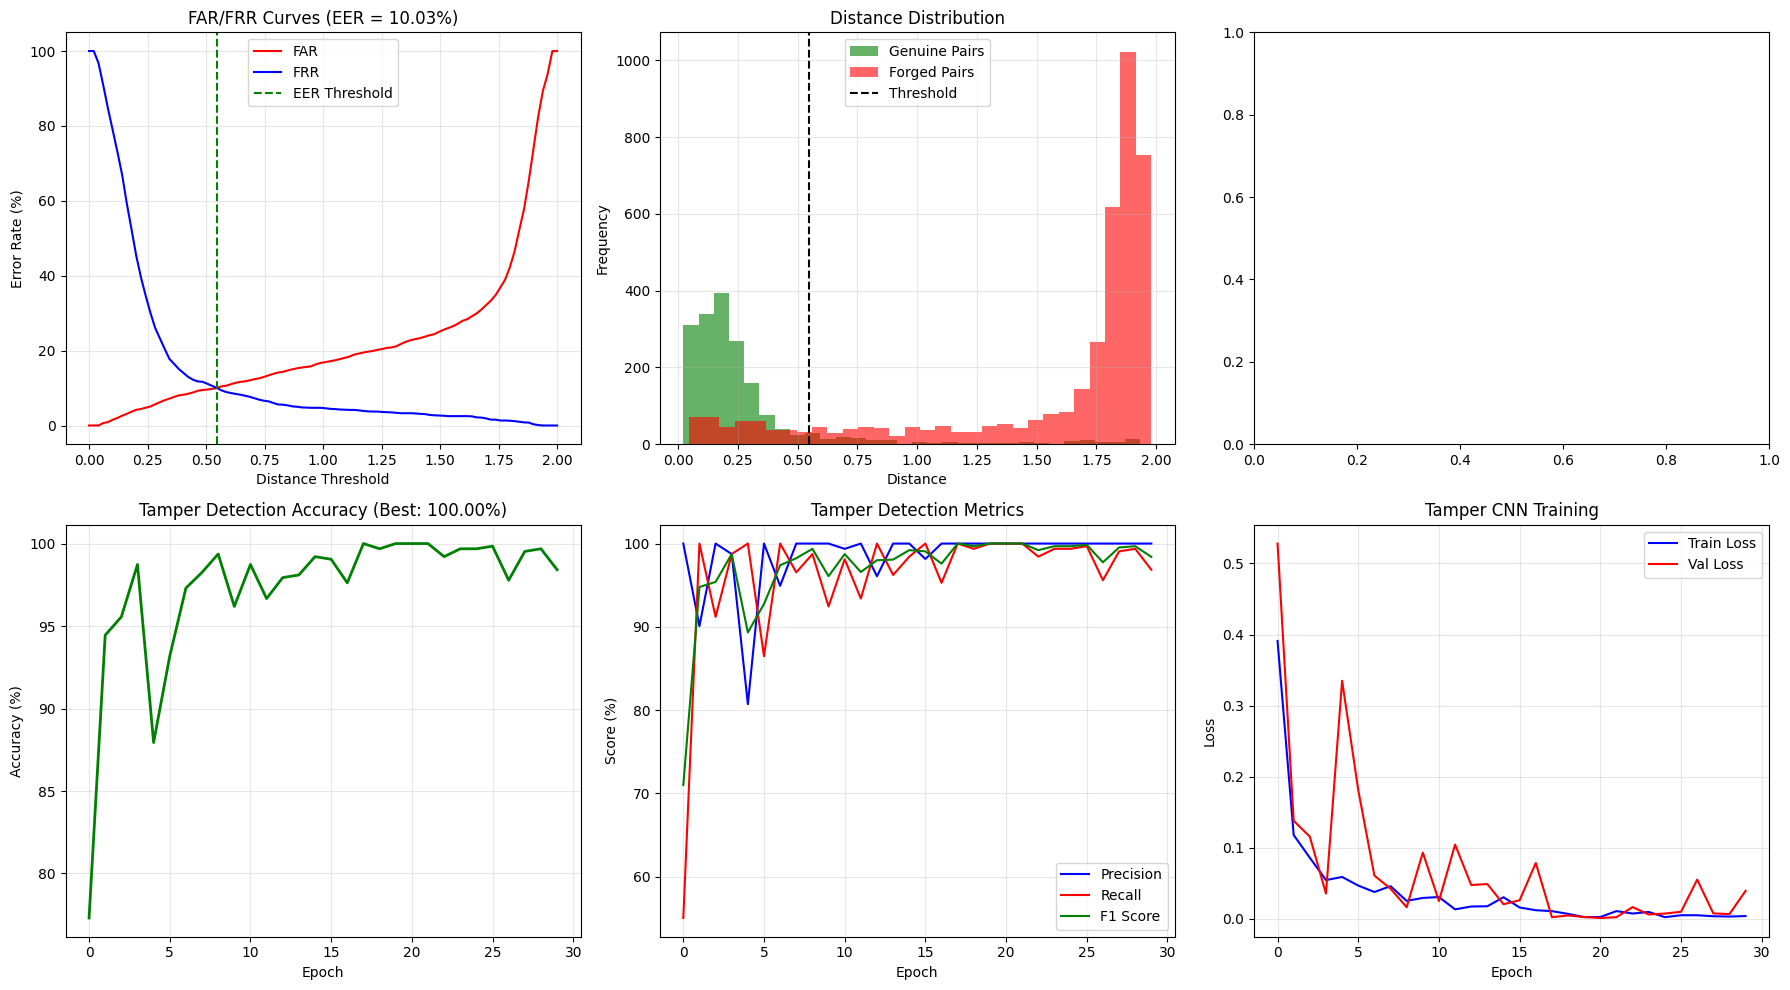


📊 Metrics plot saved to results/training_metrics.png


In [7]:
def calculate_verification_metrics(model, dataset, threshold=0.5):
    """
    Calculate FAR, FRR, EER for signature verification.

    FAR = False Acceptance Rate (forgeries accepted as genuine)
    FRR = False Rejection Rate (genuine rejected as forgeries)
    EER = Equal Error Rate (where FAR = FRR)
    """
    model.eval()

    genuine_distances = []  # Distances between genuine pairs
    forged_distances = []   # Distances between genuine and forged

    print("\n📊 Computing verification metrics...")

    with torch.no_grad():
        for user_id in tqdm(dataset.valid_users[:50], desc="Processing users"):  # Sample 50 users
            user_data = dataset.user_samples[user_id]
            genuine_paths = user_data['genuine']
            forged_paths = user_data['forged']

            if len(genuine_paths) < 2 or len(forged_paths) < 1:
                continue

            # Get embeddings for genuine signatures
            genuine_embeddings = []
            for path in genuine_paths[:10]:  # Max 10 genuine per user
                img = Image.open(path).convert('L')
                img = val_transform(img).unsqueeze(0).to(device)
                emb = model.forward_one(img)
                genuine_embeddings.append(emb)

            # Get embeddings for forged signatures
            forged_embeddings = []
            for path in forged_paths[:10]:  # Max 10 forged per user
                img = Image.open(path).convert('L')
                img = val_transform(img).unsqueeze(0).to(device)
                emb = model.forward_one(img)
                forged_embeddings.append(emb)

            # Calculate distances
            # Genuine-Genuine pairs (should be small)
            for i in range(len(genuine_embeddings)):
                for j in range(i+1, len(genuine_embeddings)):
                    dist = F.pairwise_distance(genuine_embeddings[i], genuine_embeddings[j]).item()
                    genuine_distances.append(dist)

            # Genuine-Forged pairs (should be large)
            for g_emb in genuine_embeddings:
                for f_emb in forged_embeddings:
                    dist = F.pairwise_distance(g_emb, f_emb).item()
                    forged_distances.append(dist)

    genuine_distances = np.array(genuine_distances)
    forged_distances = np.array(forged_distances)

    # Calculate FAR and FRR at different thresholds
    thresholds = np.linspace(0, 2, 100)
    fars = []
    frrs = []

    for t in thresholds:
        # FAR: forged signatures with distance < threshold (incorrectly accepted)
        far = (forged_distances < t).mean() if len(forged_distances) > 0 else 0
        # FRR: genuine signatures with distance >= threshold (incorrectly rejected)
        frr = (genuine_distances >= t).mean() if len(genuine_distances) > 0 else 0
        fars.append(far)
        frrs.append(frr)

    fars = np.array(fars)
    frrs = np.array(frrs)

    # Find EER (where FAR ≈ FRR)
    eer_idx = np.argmin(np.abs(fars - frrs))
    eer = (fars[eer_idx] + frrs[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    return {
        'far': fars[eer_idx] * 100,
        'frr': frrs[eer_idx] * 100,
        'eer': eer * 100,
        'eer_threshold': eer_threshold,
        'thresholds': thresholds,
        'fars': fars,
        'frrs': frrs,
        'genuine_distances': genuine_distances,
        'forged_distances': forged_distances
    }


def plot_metrics(siamese_metrics=None, tamper_history=None):
    """Plot all evaluation metrics"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Plot 1: FAR/FRR curves
    if siamese_metrics:
        ax = axes[0, 0]
        ax.plot(siamese_metrics['thresholds'], siamese_metrics['fars'] * 100, 'r-', label='FAR')
        ax.plot(siamese_metrics['thresholds'], siamese_metrics['frrs'] * 100, 'b-', label='FRR')
        ax.axvline(x=siamese_metrics['eer_threshold'], color='g', linestyle='--', label=f'EER Threshold')
        ax.set_xlabel('Distance Threshold')
        ax.set_ylabel('Error Rate (%)')
        ax.set_title(f"FAR/FRR Curves (EER = {siamese_metrics['eer']:.2f}%)")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Plot 2: Distance distributions
        ax = axes[0, 1]
        ax.hist(siamese_metrics['genuine_distances'], bins=30, alpha=0.6, label='Genuine Pairs', color='green')
        ax.hist(siamese_metrics['forged_distances'], bins=30, alpha=0.6, label='Forged Pairs', color='red')
        ax.axvline(x=siamese_metrics['eer_threshold'], color='black', linestyle='--', label='Threshold')
        ax.set_xlabel('Distance')
        ax.set_ylabel('Frequency')
        ax.set_title('Distance Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Plot 3: Siamese training loss
    if 'siamese_history' in dir() and siamese_history:
        ax = axes[0, 2]
        ax.plot(siamese_history['train_loss'], 'b-', label='Train Loss')
        ax.plot(siamese_history['val_loss'], 'r-', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Siamese Network Training')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Plot 4: Tamper detection accuracy
    if tamper_history:
        ax = axes[1, 0]
        ax.plot(tamper_history['accuracy'], 'g-', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy (%)')
        ax.set_title(f"Tamper Detection Accuracy (Best: {max(tamper_history['accuracy']):.2f}%)")
        ax.grid(True, alpha=0.3)

        # Plot 5: Precision, Recall, F1
        ax = axes[1, 1]
        ax.plot(tamper_history['precision'], 'b-', label='Precision')
        ax.plot(tamper_history['recall'], 'r-', label='Recall')
        ax.plot(tamper_history['f1'], 'g-', label='F1 Score')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score (%)')
        ax.set_title('Tamper Detection Metrics')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Plot 6: Training/Val Loss
        ax = axes[1, 2]
        ax.plot(tamper_history['train_loss'], 'b-', label='Train Loss')
        ax.plot(tamper_history['val_loss'], 'r-', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Tamper CNN Training')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/training_metrics.png', dpi=150)
    plt.show()
    print("\n📊 Metrics plot saved to results/training_metrics.png")


# Evaluate Siamese model
print("\n" + "="*60)
print("📈 EVALUATION METRICS")
print("="*60)

siamese_metrics = None
if len(svc_dataset) > 0:
    # Load best model
    if os.path.exists('saved_models/siamese_best.pth'):
        checkpoint = torch.load('saved_models/siamese_best.pth')
        siamese_model.load_state_dict(checkpoint['model_state_dict'])

    siamese_metrics = calculate_verification_metrics(siamese_model, svc_dataset)

    print("\n" + "="*40)
    print("🔐 SIAMESE NETWORK (Skilled Forgery Detection)")
    print("="*40)
    print(f"   FAR (False Acceptance Rate): {siamese_metrics['far']:.2f}%")
    print(f"   FRR (False Rejection Rate):  {siamese_metrics['frr']:.2f}%")
    print(f"   EER (Equal Error Rate):      {siamese_metrics['eer']:.2f}%")
    print(f"   Optimal Threshold:           {siamese_metrics['eer_threshold']:.4f}")
    print(f"   Accuracy:                    {100 - siamese_metrics['eer']:.2f}%")

# Print tamper detection metrics
if 'tamper_history' in dir() and tamper_history:
    print("\n" + "="*40)
    print("🔍 TAMPER DETECTION CNN")
    print("="*40)
    print(f"   Best Accuracy:  {max(tamper_history['accuracy']):.2f}%")
    print(f"   Best Precision: {max(tamper_history['precision']):.2f}%")
    print(f"   Best Recall:    {max(tamper_history['recall']):.2f}%")
    print(f"   Best F1 Score:  {max(tamper_history['f1']):.2f}%")

# Plot metrics
try:
    plot_metrics(siamese_metrics, tamper_history if 'tamper_history' in dir() else None)
except:
    print("⚠️ Could not generate plots (missing data)")

## 💾 Cell 8: Save Final Models for Deployment

In [8]:
# Save models with metadata
print("\n" + "="*60)
print("💾 SAVING MODELS FOR DEPLOYMENT")
print("="*60)

# Siamese model
siamese_save_path = 'saved_models/siamese_production.pth'
torch.save({
    'model_state_dict': siamese_model.state_dict(),
    'embedding_dim': 128,
    'threshold': siamese_metrics['eer_threshold'] if siamese_metrics else 0.8,
    'metrics': {
        'far': siamese_metrics['far'] if siamese_metrics else None,
        'frr': siamese_metrics['frr'] if siamese_metrics else None,
        'eer': siamese_metrics['eer'] if siamese_metrics else None,
    }
}, siamese_save_path)
print(f"✅ Siamese model saved: {siamese_save_path}")

# Tamper model
tamper_save_path = 'saved_models/tamper_production.pth'
torch.save({
    'model_state_dict': tamper_model.state_dict(),
    'metrics': {
        'accuracy': max(tamper_history['accuracy']) if 'tamper_history' in dir() and tamper_history else None,
        'precision': max(tamper_history['precision']) if 'tamper_history' in dir() and tamper_history else None,
        'recall': max(tamper_history['recall']) if 'tamper_history' in dir() and tamper_history else None,
        'f1': max(tamper_history['f1']) if 'tamper_history' in dir() and tamper_history else None,
    }
}, tamper_save_path)
print(f"✅ Tamper model saved: {tamper_save_path}")

# List saved files
print("\n📁 Saved files:")
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / (1024*1024)
    print(f"   {f} ({size:.2f} MB)")

print("\n⬇️ Download these files from the file browser to use in production.")


💾 SAVING MODELS FOR DEPLOYMENT
✅ Siamese model saved: saved_models/siamese_production.pth
✅ Tamper model saved: saved_models/tamper_production.pth

📁 Saved files:
   tamper_production.pth (10.50 MB)
   tamper_best.pth (31.48 MB)
   siamese_production.pth (43.32 MB)
   siamese_best.pth (129.84 MB)

⬇️ Download these files from the file browser to use in production.


---

# 🌐 Part 2: Flask API Server for Frontend Integration

Run this section AFTER training is complete to serve the models via API.

## 🔑 Cell 9: Setup ngrok Authentication

1. Go to https://ngrok.com and create a free account
2. Get your auth token from https://dashboard.ngrok.com/get-started/your-authtoken
3. Paste it below

In [9]:
# Enter your ngrok auth token here
NGROK_AUTH_TOKEN = "394VnWJW8qSdR1VrXST4iN3xBOQ_HSep6nr7u2Y1znQ1ZxBD"  # <-- REPLACE THIS

from pyngrok import ngrok

# Authenticate ngrok
if NGROK_AUTH_TOKEN != "YOUR_NGROK_TOKEN_HERE":
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ ngrok authenticated!")
else:
    print("⚠️ Please enter your ngrok auth token above!")
    print("   Get it from: https://dashboard.ngrok.com/get-started/your-authtoken")

✅ ngrok authenticated!


## 🚀 Cell 10: Start Flask API Server

---

# 📖 Quick Reference

## Complete Workflow

1. **Upload datasets** (ZIP files via Colab file browser)
2. **Run Cells 1-4** to load and prepare data
3. **Run Cells 5-6** to train both models
4. **Run Cell 7** to evaluate and see metrics
5. **Run Cell 8** to save models
6. **Run Cells 9-10** to start the API server
7. **Copy the ngrok URL** to your frontend `.env.local`

## Expected Metrics

| Model | Metric | Target |
|-------|--------|--------|
| Siamese | EER | < 10% |
| Siamese | Accuracy | > 90% |
| Tamper | Accuracy | > 95% |
| Tamper | F1 Score | > 90% |

## Troubleshooting

- **Out of memory**: Reduce batch size to 16
- **Slow training**: Reduce epochs or use smaller dataset
- **ngrok error**: Get a free token from ngrok.com
- **Frontend can't connect**: Check that ngrok URL is correct in .env.local

In [10]:
# ============================================================
# CELL: Flask API — REPLACE YOUR EXISTING FLASK CELL
# ============================================================
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import io, base64, time, hashlib
import threading

# Kill existing servers
os.system("kill -9 $(lsof -t -i:5000) 2>/dev/null")
time.sleep(2)

app = Flask(__name__)
CORS(app)

# --- Deterministic inference ---
def set_deterministic():
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    np.random.seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- Deterministic transform (NO random augmentation) ---
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- Load models ---
if os.path.exists('saved_models/siamese_production.pth'):
    ckpt = torch.load('saved_models/siamese_production.pth', map_location=device, weights_only=False)
    siamese_model.load_state_dict(ckpt['model_state_dict'])
elif os.path.exists('saved_models/siamese_best.pth'):
    ckpt = torch.load('saved_models/siamese_best.pth', map_location=device, weights_only=False)
    siamese_model.load_state_dict(ckpt['model_state_dict'])

if os.path.exists('saved_models/tamper_production.pth'):
    ckpt = torch.load('saved_models/tamper_production.pth', map_location=device, weights_only=False)
    tamper_model.load_state_dict(ckpt['model_state_dict'])
elif os.path.exists('saved_models/tamper_best.pth'):
    ckpt = torch.load('saved_models/tamper_best.pth', map_location=device, weights_only=False)
    tamper_model.load_state_dict(ckpt['model_state_dict'])

siamese_model.eval()
tamper_model.eval()
print("✅ Models loaded and set to eval()")

# --- Thresholds (calibrate on your validation set) ---
SIAMESE_AUTHENTIC_THRESHOLD = 0.75  # cosine score above = authentic
SIAMESE_FORGED_THRESHOLD = 0.50     # cosine score below = forged
TAMPER_CONFIDENCE_THRESHOLD = 0.80  # only trust tamper if >80%

# --- Helpers ---
def get_image_hash(b64):
    if ',' in b64: b64 = b64.split(',')[1]
    return hashlib.md5(b64.encode()).hexdigest()

def preprocess_image(b64):
    if ',' in b64: b64 = b64.split(',')[1]
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert('L')
    return val_transform(img).unsqueeze(0).to(device)

# --- Routes ---
@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'device': str(device)})

@app.route('/verify', methods=['POST'])
def verify_signature():
    try:
        set_deterministic()  # ✅ Deterministic EVERY request

        data = request.get_json()
        ref_b64 = data.get('reference', '')
        test_b64 = data.get('test', '')
        if not ref_b64 or not test_b64:
            return jsonify({'error': 'Missing images'}), 400

        # Identical image check
        if get_image_hash(ref_b64) == get_image_hash(test_b64):
            return jsonify({
                'result': 'genuine', 'confidence': 0.99,
                'siameseScore': 0.99, 'tamperScore': 0.01,
                'distance': 0.0,
                'details': {'strokeConsistency': 0.99, 'pressurePattern': 0.99,
                           'spatialAlignment': 0.99, 'pixelAnomalies': 0.01}
            })

        ref_t = preprocess_image(ref_b64)
        test_t = preprocess_image(test_b64)

        with torch.no_grad():
            # === STEP 1: SIAMESE (primary, well-trained) ===
            ref_emb = siamese_model.forward_one(ref_t)
            test_emb = siamese_model.forward_one(test_t)
            distance = F.pairwise_distance(ref_emb, test_emb).item()
            cosine_sim = F.cosine_similarity(ref_emb, test_emb).item()
            siamese_score = (cosine_sim + 1) / 2  # normalize to 0-1

            # === STEP 2: TAMPER (secondary safety net) ===
            tamper_out = tamper_model(test_t)
            tamper_probs = F.softmax(tamper_out, dim=1)
            raw_tamper = tamper_probs[0, 1].item()

            # === DECISION LOGIC: Siamese-first ===
            if siamese_score >= SIAMESE_AUTHENTIC_THRESHOLD:
                # Siamese says authentic — check tamper as safety
                if raw_tamper > TAMPER_CONFIDENCE_THRESHOLD:
                    result = 'tampered'
                    confidence = raw_tamper
                else:
                    result = 'genuine'
                    confidence = 0.70 + (siamese_score - SIAMESE_AUTHENTIC_THRESHOLD) / (1 - SIAMESE_AUTHENTIC_THRESHOLD) * 0.29
            elif siamese_score < SIAMESE_FORGED_THRESHOLD:
                # Clearly forged
                result = 'forged'
                confidence = 0.75 + (SIAMESE_FORGED_THRESHOLD - siamese_score) / SIAMESE_FORGED_THRESHOLD * 0.24
            else:
                # Ambiguous — use tamper as tiebreaker
                if raw_tamper > TAMPER_CONFIDENCE_THRESHOLD:
                    result = 'tampered'
                    confidence = raw_tamper
                else:
                    result = 'forged'
                    confidence = 0.55 + (SIAMESE_AUTHENTIC_THRESHOLD - siamese_score) / (SIAMESE_AUTHENTIC_THRESHOLD - SIAMESE_FORGED_THRESHOLD) * 0.20

            confidence = round(min(max(confidence, 0.0), 0.99), 4)

            # Embedding-based detail metrics
            ref_flat = ref_emb.cpu().numpy().flatten()
            test_flat = test_emb.cpu().numpy().flatten()
            def safe_corr(a, b):
                try: return max(0.0, min(1.0, abs(np.corrcoef(a, b)[0, 1])))
                except: return 0.5
            chunk = len(ref_flat) // 4

        return jsonify({
            'result': result,
            'confidence': confidence,
            'siameseScore': round(siamese_score, 4),
            'tamperScore': round(raw_tamper, 4),
            'distance': round(distance, 4),
            'details': {
                'strokeConsistency': round(safe_corr(ref_flat[:chunk], test_flat[:chunk]), 4),
                'pressurePattern': round(safe_corr(ref_flat[chunk:2*chunk], test_flat[chunk:2*chunk]), 4),
                'spatialAlignment': round(safe_corr(ref_flat[2*chunk:3*chunk], test_flat[2*chunk:3*chunk]), 4),
                'pixelAnomalies': round(raw_tamper, 4)
            }
        })

    except Exception as e:
        import traceback
        traceback.print_exc()
        return jsonify({'error': str(e)}), 500

# --- Start server ---
ngrok.kill()
time.sleep(1)
public_url = ngrok.connect(5000)
url_str = str(public_url)
clean_url = url_str.split('"')[1] if '"' in url_str else url_str
print(f"\n🌐 API URL: {clean_url}")
print(f"VITE_API_URL={clean_url}")

def run_flask():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

threading.Thread(target=run_flask, daemon=True).start()
time.sleep(2)
print("✅ SERVER RUNNING")


✅ Models loaded and set to eval()

🌐 API URL: https://gregoria-proconviction-earline.ngrok-free.dev
VITE_API_URL=https://gregoria-proconviction-earline.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


✅ SERVER RUNNING
